In [2]:
import sklearn 
import numpy as np

In [3]:
import pandas as pd

# Data processing
patients = pd.read_csv('patients.csv')
diagnoses = pd.read_csv('diagnoses.csv')
outcomes = pd.read_csv('outcomes.csv')
labs=pd.read_csv('labs.csv')

In [4]:
patients = patients.merge(diagnoses, on = 'DiagnosisID')
patients = patients.merge(outcomes, on = 'OutcomeID')

In [5]:
patients['AdmissionDate']=pd.to_datetime(patients['AdmissionDate'])
patients['DischargeDate']=pd.to_datetime(patients['DischargeDate'])
patients['LengthofStay']=(patients['DischargeDate']-patients['AdmissionDate']).dt.days

In [6]:
patients['OutcomeEncoded']=patients['OutcomeName'].map({'Recovered':0 , 'Complicated':1, 'Deceased':1})

In [7]:
patients['HighRisk']=np.where((patients['Age']>65)|(patients['OutcomeName'].isin(['Complicated','Deceased'])),1,0)

In [8]:
abnormal_conditions={
    'Blood Sugar':lambda x: x>120,
    'Cholestrol':lambda x: x>200,
    'Haemoglobin': lambda x:x<13
}

def count_abnormallabs(patient_id):
    patient_labs=labs[labs['PatientID']==patient_id]
    count=0
    for test_name,condition in abnormal_conditions.items():
        test_results=patient_labs[patient_labs['TestName']== test_name]
        count+= test_results['Result'].apply(condition).sum()
    return count

patients['AbnormalLabcount']=patients['PatientID'].apply(count_abnormallabs) 

Model Training

In [9]:
features=patients[['Age','LengthofStay','TreatmentCost']]
target=patients['OutcomeEncoded']

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test=train_test_split(features,target,test_size=0.3,random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression(max_iter=500)
model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred=model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.72      1.00      0.83        43

    accuracy                           0.72        60
   macro avg       0.36      0.50      0.42        60
weighted avg       0.51      0.72      0.60        60



c:\Users\gamin\Downloads\HealthcareDBproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gamin\Downloads\HealthcareDBproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gamin\Downloads\HealthcareDBproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

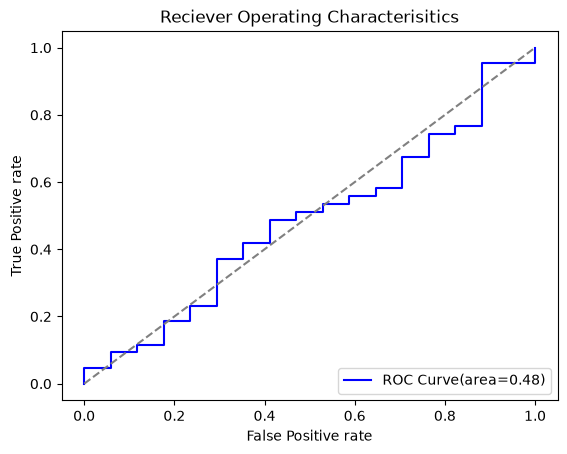

In [13]:
import matplotlib.pyplot as plt     
from sklearn.metrics import roc_curve,auc
y_prob=model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
roc_auc=auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr,color='blue',label=f'ROC Curve(area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate')
plt.title('Reciever Operating Characterisitics')
plt.legend(loc="lower right")
plt.show()

In [18]:
import joblib
import os

joblib.dump(model, 'riskmodel1.pkl')
print("Model successfully saved to: riskmodel1.pkl")

Model successfully saved to: riskmodel1.pkl
